In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [3]:
image_cut = image[55:155, 0:1800]

Text(0.5, 0, 'wavelenght')

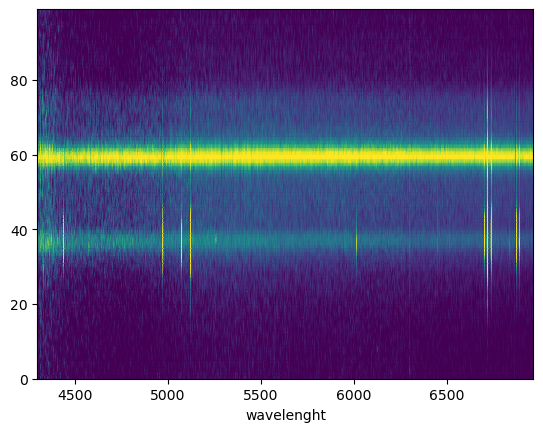

In [4]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [5]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

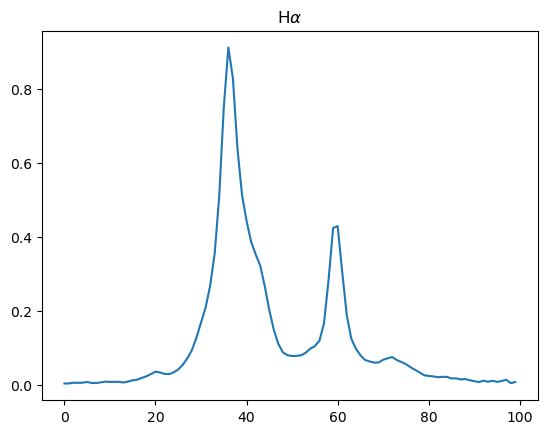

In [7]:
mask_HA = (wavelenghts > l_HA-10)*(wavelenghts < l_HA+10)
image_HA = image_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')

### Fit con gaussian 1d kernel no grid

In [ ]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

def model_convolved(x, *params):
    """ Somma di 4 Sérsic convoluti """
    return (
        sersic_1d_convolved(x, *params[0:4]) +
        sersic_1d_convolved(x, *params[4:8]) +
        sersic_1d_convolved(x, *params[8:12]) +
        sersic_1d_convolved(x, *params[12:16])
    )

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

In [ ]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

plt.savefig('Radial_profile_Halpha_kernel')

### Fit con kernel e griglia 

In [ ]:
sigma = 3.125/2.35

def calculate_bn(n): #Evaluate B_n for the sersic profile 
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0): #Sersic profile centered in x0
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))

def sersic_1d_convolved(x, I_e, r_e, n, x_0): #Convolved sersic profile with the psf
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   #The PSF is a gaussian centered in 0!
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def model_convolved(x, *params):
    return (sersic_1d_convolved(x, *params[0:4]) + sersic_1d_convolved(x, *params[4:8]) + sersic_1d_convolved(x, *params[8:12]) +
        sersic_1d_convolved(x, *params[12:16])) 

def chi_squared(params, x, y_obs):
    #I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03, I_e4, r_e4, n4, x_04 = params
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

bounds = [(0, 0.1), (2, 20), (0.1, 10), (20, 40),   (0., 0.1), (2, 20), (0.1, 10), (40, 50), 
          (0., 0.1), (2, 20), (0.1, 10), (53, 60),   (0., 0.1), (2, 20), (0.1, 10), (65, 75) ]

def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)
    
result = differential_evolution(objective, bounds, maxiter = 200, disp = True, polish = True, tol = 1e-6)
best_params = result.x

xgrid = np.linspace(0, 100, 200)
y_fit = model_convolved(xgrid, *best_params)
y_fit_data = model_convolved(x_axes, *best_params)

plt.figure(figsize=(8, 6))
plt.plot(x_axes, radial_profile_HA, label='Dati')
plt.plot(xgrid, y_fit, 'r-', label='Fit convoluto')

# Componenti singoli
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), 'orange', linestyle='--', label='Sérsic 4')

plt.xlabel("Raggio [pixel]")
plt.ylabel("Intensità")
plt.title(r"Fit H$\alpha$ convoluto con PSF (minimize)")
plt.legend()
plt.show()
print("Parametri ottimizzati 1:\n", best_params[0:4])
print("Parametri ottimizzati 2:\n", best_params[4:8])
print("Parametri ottimizzati 3:\n", best_params[8:12])
print("Parametri ottimizzati 4:\n", best_params[12:16])

plt.plot(x_axes, radial_profile_HA - y_fit_data)
plt.ylim(-0.2, 0.2)